In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("/home/vs428/Documents/Uncertainty")

In [2]:
from llm_funcs import compute_true_bayesian_update

# Read in Student Annotations

In [3]:
import pyreadstat
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

df, meta = pyreadstat.read_sav('/home/vs428/project/Uncertainty_data/BRUSH NEW DATA with neg test data reversed.sav')


In [4]:
display(df.head())
print(meta.column_names)
print(meta.column_labels)
print(meta.column_names_to_labels)
print(meta.number_rows)
print(meta.number_columns)
print(meta.file_label)
print(meta.file_encoding)
# # there are other metadata pieces extracted. See the documentation for more details.

,CONDITION,School,id,TimehrsSession2Session1,I01,CHF01testL,CHF01btestL,posneg1,Sens1,Spec1,...,Dem13Time,Condition2,V281,V282,V283,V284,TotalTimemin18minvideoand3cases,@18min.Videotimeonlymin,V287,V288
0,1.0,McMaster,1.0,90.008056,NaN,65.0,60.0,NEG,54.0,96.0,...,13.12,1.0,NaN,NaN,NaN,(1) Video Condition,62.681500,50.351667,NaN,NaN
1,1.0,McMaster,2.0,29.465000,NaN,10.0,7.0,,54.0,96.0,...,9.78,1.0,NaN,NaN,NaN,,14.570667,8.759667,NaN,NaN
2,1.0,McMaster,3.0,41.366389,NaN,5.0,2.0,,54.0,96.0,...,12.83,1.0,NaN,NaN,NaN,,14.522167,7.594833,NaN,NaN
3,1.0,EVMS,4.0,52.859167,NaN,10.0,4.0,,54.0,96.0,...,10.49,1.0,NaN,NaN,NaN,,5.430167,0.286167,NaN,NaN
4,1.0,McMaster,5.0,40.043889,NaN,2.0,1.0,,54.0,96.0,...,12.98,1.0,NaN,NaN,NaN,,29.793000,20.782333,NaN,NaN


['CONDITION', 'School', 'id', 'TimehrsSession2Session1', 'I01', 'CHF01testL', 'CHF01btestL', 'posneg1', 'Sens1', 'Spec1', 'Bayes1', 'Diff1', 'diff1sq', 'Err1', 'ES1', 'CHF02testM', 'CHF02btestM', 'posneg2', 'Sens2', 'Spec2', 'Bayes2', 'Diff2', 'Diff2sq', 'Err2', 'ES2', 'CHF03testH', 'CHF03btestH', 'posneg3', 'Sens3', 'Spec3', 'Bayes3', 'Diff3', 'Diff3sq', 'Err3', 'ES3', 'CHF04testM', 'CHF04btestM', 'posneg4', 'Sens4', 'Spec4', 'Bayes4', 'Diff4', 'Diff4sq', 'Err4', 'ES4', 'Pye05testF', 'Pye05btestF', 'posneg5', 'Sens5', 'Spec5', 'Bayes5', 'Diff5', 'Err5', 'ES5', 'Cry06testF', 'Cry06btestF', 'posneg6', 'Sens6', 'Spec6', 'Bayes6', 'Diff6', 'Err6', 'ES6', 'PEm07testM', 'PEm07btestM', 'posneg7', 'Sens7', 'Spec7', 'Bayes7', 'Diff7', 'Diff7sq', 'Err7', 'ES7', 'PEm08testH', 'PEm08btestH', 'posneg8', 'Sens8', 'Spec8', 'Bayes8', 'Diff8', 'Diff8sq', 'Err8', 'ES8', 'PEm09testM', 'PEm09btestM', 'posneg9', 'Sens9', 'Spec9', 'Bayes9', 'Diff9', 'Diff9sq', 'Err9', 'ES9', 'PEm10testL', 'PEm10btestL', 'p

In [5]:
# we should probably run Pyelo, Cry, Chl, and SAH at some point too, but for now, we just stick with the 4 we have. 
# df.columns[df.columns.str.contains("|".join(['CHF', "Pye", 'Cry', 'PE',  'Chl', 'SAH', 'ACS', 'Pna'])) & ~df.columns.str.contains("Time")]

In [6]:
df.columns[df.columns.str.contains("|".join(['CHF',  'PE', 'ACS', 'Pna'])) & ~df.columns.str.contains("Time") & ~df.columns.str.contains("btest")]

Index(['CHF01testL', 'CHF02testM', 'CHF03testH', 'CHF04testM', 'PEm07testM',
       'PEm08testH', 'PEm09testM', 'PEm10testL', 'ACS13testH', 'ACS14testL',
       'ACS15testM', 'ACS16testM', 'Pna17testH', 'Pna18testM', 'Pna19testM',
       'Pna20testL'],
      dtype='object')

In [7]:
df.columns[df.columns.str.contains("|".join(['CHF',  'PE', 'ACS', 'Pna'])) & ~df.columns.str.contains("Time") & ~df.columns.str.contains(r"\ntest", regex=True)]

Index(['CHF01testL', 'CHF01btestL', 'CHF02testM', 'CHF02btestM', 'CHF03testH',
       'CHF03btestH', 'CHF04testM', 'CHF04btestM', 'PEm07testM', 'PEm07btestM',
       'PEm08testH', 'PEm08btestH', 'PEm09testM', 'PEm09btestM', 'PEm10testL',
       'PEm10btestL', 'ACS13testH', 'ACS13btestH', 'ACS14testL', 'ACS14btestL',
       'ACS15testM', 'ACS15btestM', 'ACS16testM', 'ACS16btestM', 'Pna17testH',
       'Pna17btestH', 'Pna18testM', 'Pna18btestM', 'Pna19testM', 'Pna19btestM',
       'Pna20testL', 'Pna20btestL'],
      dtype='object')

In [8]:
df.columns[df.columns.str.contains('11')]

Index(['Chl11testF', 'Chl11btestT', 'posneg11', 'Sens11', 'Spec11', 'Bayes11',
       'Diff11', 'Diff11sq', 'Err11', 'ES11', 'Chl11testFTime',
       'Chl11btestTTime'],
      dtype='object')

## Figure out which of all the cases we have Physician data for

In [9]:
import pandas as pd

In [10]:
data = pd.read_csv("/home/vs428/project/Uncertainty_data/all_cases_clean.csv", sep="|",  engine="c")


In [11]:
data['case'] = data['case'].str.replace("“", '"')
data['case'] = data['case'].str.replace("”", '"')
data['case'] = data['case'].str.replace("’", "'")
data['case'] = data['case'].str.replace("½", "1/2")
data['case'] = data['case'].str.replace("–", "-")

In [12]:
for case in data['case'].tolist():
    try:
        case.encode('ascii')
    except UnicodeDecodeError:
        print("it was not a ascii-encoded unicode string")

In [13]:
# the rest we don't have data for, so we set them to 0
data['physician_estimates'] = 0

In [14]:
# Rows with both GPT and Physician estimates

# CHF-4: 13, 19, 24, 21
# Pye-1: 
# Cry-1: 
# PE-4: 35, 40, 34, 33
# Chl-1: 
# SAH-1: 
# ACS-4: 10, 2, 6, 8
# Pna-4: 29, 27, 28, 26

# the rows that we have physician data for (some of them were for training purposes for EXPERIENTIAL GROUP so we don't have data for them)
data.iloc[[13, 19, 24, 21],  data.columns.get_loc('physician_estimates')] = 1
data.iloc[[35, 40, 34, 33],  data.columns.get_loc('physician_estimates')] = 1
data.iloc[[10, 2, 6, 8],  data.columns.get_loc('physician_estimates')] = 1
data.iloc[[29, 27, 28, 26],  data.columns.get_loc('physician_estimates')] = 1

In [15]:
# for idx, case in enumerate(data['case']):
#     print(f"==================== Case Number: {idx} ====================")
#     print(case)
    

In [16]:
# 27 cases (9 for each condition) for experience group -> no data
# 16 cases (4 for 4 conditions) for test cases to compare against -> has data
data['physician_estimates'].value_counts()

physician_estimates
0    27
1    16
Name: count, dtype: int64

In [17]:
data[data['case_type'].isin(['ACS', "Pulmonary Embolism"])].shape[0] + 9

35

In [18]:
# with pd.option_context("display.max_colwidth", None):
#     display(data[data['physician_estimates'] == 0][['probability', "differential", "case"]])

## Clean Data

In [19]:
# drop the empty row
df = df[~df['id'].isna()]

In [20]:
# replace posneg values so they're all filled out
df[df.columns[df.columns.str.contains("posneg")]] = df[df.columns[df.columns.str.contains("posneg")]].replace(r'^\s*$', np.nan, regex=True).ffill(axis=0)

In [21]:
df['CONDITION'] = df['CONDITION'].replace(1, "CONCEPT") 
df['CONDITION'] = df['CONDITION'].replace(2, "EXPERIENCE") 
df['CONDITION'] = df['CONDITION'].replace(3, "CONTROL") 

## Reorganize physician estimate data

In [22]:
# this outputs both the condition, raw string IDs and a number for the next step
case_ids_of_interest = [(x[:-7], x[-7:-5], int(x[-7:-5])) for x in df.columns[df.columns.str.contains("|".join(['CHF',  'PE', 'ACS', 'Pna'])) & ~df.columns.str.contains("Time") & ~df.columns.str.contains("btest")].tolist()]

In [23]:
case_ids_of_interest

[('CHF', '01', 1),
 ('CHF', '02', 2),
 ('CHF', '03', 3),
 ('CHF', '04', 4),
 ('PEm', '07', 7),
 ('PEm', '08', 8),
 ('PEm', '09', 9),
 ('PEm', '10', 10),
 ('ACS', '13', 13),
 ('ACS', '14', 14),
 ('ACS', '15', 15),
 ('ACS', '16', 16),
 ('Pna', '17', 17),
 ('Pna', '18', 18),
 ('Pna', '19', 19),
 ('Pna', '20', 20)]

In [24]:
# df cols: case_type, case_num, pre, post, diff, posneg, probability
# diff doesn't seem to make any sense, so we dropped it
dfs = []
for case_type, string_id, idx in case_ids_of_interest:
    case_df = df[df.columns.intersection([f'{case_type}{string_id}testL', f'{case_type}{string_id}btestL', 
                f'{case_type}{string_id}testM', f'{case_type}{string_id}btestM',
                f'{case_type}{string_id}testH', f'{case_type}{string_id}btestH',
                f'posneg{idx}', 
                "CONDITION",
                # f"Diff{idx}",                                        
                # f'Sens{idx}', f'Spec{idx}', 
                # f'Bayes{idx}'
               ])]

    col_map = {case_df.columns[case_df.columns.str.contains(r"\dtest", regex=True)].tolist()[0]:"pretest_prob",
              case_df.columns[case_df.columns.str.contains(r"btest", regex=True)].tolist()[0]:"posttest_prob",
              f"posneg{idx}":"positive"}
    reform_df = case_df.rename(col_map, axis=1)
    reform_df['case_type'] = case_type
    reform_df['jbrush_case_num'] = idx
    reform_df['case_type'] = case_type
    reform_df['CONDITION'] = case_df['CONDITION']
    
    if case_df.columns[case_df.columns.str.contains(r"\dtest", regex=True)].tolist()[0][-1] == "H":
        prob = "high"
    elif case_df.columns[case_df.columns.str.contains(r"\dtest", regex=True)].tolist()[0][-1] == "M":
        prob = "medium"
    elif case_df.columns[case_df.columns.str.contains(r"\dtest", regex=True)].tolist()[0][-1] == "L":
        prob = "low"
    else:
        re_str = r'\dtest'
        raise Exception(f"Weird prob: {case_df.columns[case_df.columns.str.contains(re_str, regex=True)].tolist()[0]}")
    
    reform_df['probability'] = prob
    dfs.append(reform_df)

In [25]:
reformed_df = pd.concat(dfs, axis=0)

In [26]:
reformed_df['case_type'] = reformed_df['case_type'].replace("CHF", "CHF") 
reformed_df['case_type'] = reformed_df['case_type'].replace("PEm", "Pulmonary Embolism") 
reformed_df['case_type'] = reformed_df['case_type'].replace("ACS", "ACS") 
reformed_df['case_type'] = reformed_df['case_type'].replace("Pna", "Pneumonia") 

In [27]:
# provide the likelihood ratios for each case, whether it's positive or negative
for case in ['CHF', 'Pulmonary Embolism', 'ACS', 'Pneumonia']:
    reformed_df.loc[(reformed_df['case_type'] == case) & (reformed_df['positive'] == "POS"), "lr"] = data[data['physician_estimates'].astype(bool)].groupby("case_type").first().loc[case]['pos_lr']
    reformed_df.loc[(reformed_df['case_type'] == case) & (reformed_df['positive'] == "NEG"), "lr"] = data[data['physician_estimates'].astype(bool)].groupby("case_type").first().loc[case]['neg_lr']

## Compute True Bayesian Update scores

In [28]:
reformed_df['true_posttest'] = reformed_df.apply(lambda row: compute_true_bayesian_update(row['pretest_prob'] / 100, row['lr']) * 100, axis=1)

In [29]:
reformed_df['bayes_diff'] = reformed_df['true_posttest'] - reformed_df['posttest_prob']

## Plot Physician Estimates By Condition

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Physician Bayesian Estimation by Condition')

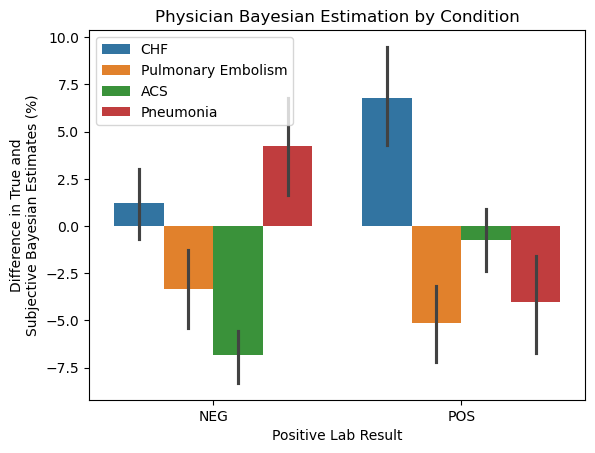

In [31]:
# just show the physician estimates to validate
fig = sns.barplot(reformed_df, x="positive", y='bayes_diff', hue="case_type")
plt.ylabel("Difference in True and\nSubjective Bayesian Estimates (%)")
plt.xlabel("Positive Lab Result")
plt.legend( loc = 'upper left')
plt.title("Physician Bayesian Estimation by Condition")

# Read in GPT Results

In [32]:
baseline_large = pd.read_csv("/home/vs428/project/Uncertainty_data/smdm/baseline-decile-gpt-4o-0.8_results-smdm-v1.csv")
baseline_mini = pd.read_csv("/home/vs428/project/Uncertainty_data/smdm/baseline-decile-gpt-4o-mini-0.8_results-smdm-v1.csv")
noCoT_large = pd.read_csv("/home/vs428/project/Uncertainty_data/smdm/noCoT-decile-gpt-4o-0.8_results-smdm-v1.csv")
noCoT_mini = pd.read_csv("/home/vs428/project/Uncertainty_data/smdm/noCoT-decile-gpt-4o-mini-0.8_results-smdm-v1.csv")
noLR_large = pd.read_csv("/home/vs428/project/Uncertainty_data/smdm/noLR-decile-gpt-4o-0.8_results-smdm-v1.csv")
noLR_mini = pd.read_csv("/home/vs428/project/Uncertainty_data/smdm/noLR-decile-gpt-4o-mini-0.8_results-smdm-v1.csv")

In [33]:
baseline_large = baseline_large.drop_duplicates(subset=['trialnum',  'vignetteid', 'positive'], keep="first")
baseline_mini = baseline_mini.drop_duplicates(subset=['trialnum',  'vignetteid', 'positive'], keep="first")
noCoT_large = noCoT_large.drop_duplicates(subset=['trialnum',  'vignetteid', 'positive'], keep="first")
noCoT_mini = noCoT_mini.drop_duplicates(subset=['trialnum',  'vignetteid', 'positive'], keep="first")
noLR_large = noLR_large.drop_duplicates(subset=['trialnum',  'vignetteid', 'positive'], keep="first")
noLR_mini = noLR_mini.drop_duplicates(subset=['trialnum',  'vignetteid', 'positive'], keep="first")

In [34]:
# get the LRs for calculation of the missed values
baseline_large = baseline_large.merge(data[['index', "pos_lr", "neg_lr", "case_type"]], left_on="vignetteid", right_on="index", how="left")
baseline_mini = baseline_mini.merge(data[['index', "pos_lr", "neg_lr", "case_type"]], left_on="vignetteid", right_on="index", how="left")
noCoT_large = noCoT_large.merge(data[['index', "pos_lr", "neg_lr", "case_type"]], left_on="vignetteid", right_on="index", how="left")
noCoT_mini = noCoT_mini.merge(data[['index', "pos_lr", "neg_lr", "case_type"]], left_on="vignetteid", right_on="index", how="left")
noLR_large = noLR_large.merge(data[['index', "pos_lr", "neg_lr", "case_type"]], left_on="vignetteid", right_on="index", how="left")
noLR_mini  = noLR_mini .merge(data[['index', "pos_lr", "neg_lr", "case_type"]], left_on="vignetteid", right_on="index", how="left")

In [35]:
parse_errors_baseline_large = baseline_large[(baseline_large['est_sensitivity'] == "PARSEERROR") | (baseline_large['est_specificity'] == "PARSEERROR") | (baseline_large['est_pretest_prob'] == "PARSEERROR")  | (baseline_large['est_posttest_prob'] == "PARSEERROR")].index

parse_errors_baseline_mini = baseline_mini[(baseline_mini['est_sensitivity'] == "PARSEERROR") | (baseline_mini['est_specificity'] == "PARSEERROR") | (baseline_mini['est_pretest_prob'] == "PARSEERROR")  | (baseline_mini['est_posttest_prob'] == "PARSEERROR")].index

parse_errors_noCoT_large = noCoT_large[(noCoT_large['est_sensitivity'] == "PARSEERROR") | (noCoT_large['est_specificity'] == "PARSEERROR") | (noCoT_large['est_pretest_prob'] == "PARSEERROR")  | (noCoT_large['est_posttest_prob'] == "PARSEERROR")].index

parse_errors_noCoT_mini = noCoT_mini[(noCoT_mini['est_sensitivity'] == "PARSEERROR") | (noCoT_mini['est_specificity'] == "PARSEERROR") | (noCoT_mini['est_pretest_prob'] == "PARSEERROR")  | (noCoT_mini['est_posttest_prob'] == "PARSEERROR")].index

parse_errors_noLR_large = noLR_large[(noLR_large['est_sensitivity'] == "PARSEERROR") | (noLR_large['est_specificity'] == "PARSEERROR") | (noLR_large['est_pretest_prob'] == "PARSEERROR")  | (noLR_large['est_posttest_prob'] == "PARSEERROR")].index

parse_errors_noLR_mini = noLR_mini[(noLR_mini['est_sensitivity'] == "PARSEERROR") | (noLR_mini['est_specificity'] == "PARSEERROR") | (noLR_mini['est_pretest_prob'] == "PARSEERROR")  | (noLR_mini['est_posttest_prob'] == "PARSEERROR")].index


In [36]:
parse_errors_baseline_large, parse_errors_baseline_mini, parse_errors_noCoT_large, parse_errors_noCoT_mini, parse_errors_noLR_large, parse_errors_noLR_mini

(Index([13, 19, 53, 68, 72, 73, 89, 250, 346], dtype='int64'),
 Index([192, 286, 391], dtype='int64'),
 Index([51], dtype='int64'),
 Index([], dtype='int64'),
 Index([8, 17, 51, 85, 92, 148, 214, 221, 342], dtype='int64'),
 Index([58, 336], dtype='int64'))

In [37]:
# parse_errors_baseline_large

In [38]:
# reset the errors and remove the ones that we don't have enough data to code by hand
# later we'll drop all the rest of the PARSEERRORS
parse_errors_baseline_large = pd.Index([19, 89, 250, 346])
# parse_errors_noCoT_large the only error that exists is a true error
parse_errors_noCoT_large = pd.Index([])
parse_errors_noLR_large = pd.Index([148, 214, 221, 342])

In [39]:
baseline_large_missed_pretest = [90, 5, 80, 1]
baseline_large_missed_posttest = [35.1, 0.3146, 87.2, 4.58]

baseline_mini_missed_pretest = [85, 15, 85]
baseline_mini_missed_posttest = [96.4, 70.32, 73.91]

noLR_large_missed_pretest = [1, 90, 95, 80]
noLR_large_missed_posttest = [5, 98, 80, 90]

noLR_mini_missed_pretest = [85, 85]
noLR_mini_missed_posttest = [95, 80]

In [40]:
import numpy as np
# Fix all GPT 4o-mini answers
baseline_large.loc[parse_errors_baseline_large, ["est_pretest_prob", "est_posttest_prob"]] = np.array([baseline_large_missed_pretest, baseline_large_missed_posttest]).T
baseline_mini.loc[parse_errors_baseline_mini, ["est_pretest_prob", "est_posttest_prob"]] = np.array([baseline_mini_missed_pretest, baseline_mini_missed_posttest]).T

noCoT_large.loc[parse_errors_noCoT_large, ["est_pretest_prob", "est_posttest_prob"]] = np.array([[], []]).T
noCoT_mini.loc[parse_errors_noCoT_mini, ["est_pretest_prob", "est_posttest_prob"]] = np.array([[], []]).T

noLR_large.loc[parse_errors_noLR_large, ["est_pretest_prob", "est_posttest_prob"]] = np.array([noLR_large_missed_pretest, noLR_large_missed_posttest]).T
noLR_mini.loc[parse_errors_noLR_mini, ["est_pretest_prob", "est_posttest_prob"]] = np.array([noLR_mini_missed_pretest, noLR_mini_missed_posttest]).T


In [41]:
baseline_large = baseline_large[~((baseline_large['est_sensitivity'] == "PARSEERROR") | (baseline_large['est_specificity'] == "PARSEERROR") | (baseline_large['est_pretest_prob'] == "PARSEERROR")  | (baseline_large['est_posttest_prob'] == "PARSEERROR"))]
baseline_mini = baseline_mini[~((baseline_mini['est_sensitivity'] == "PARSEERROR") | (baseline_mini['est_specificity'] == "PARSEERROR") | (baseline_mini['est_pretest_prob'] == "PARSEERROR")  | (baseline_mini['est_posttest_prob'] == "PARSEERROR"))]
noCoT_large = noCoT_large[~((noCoT_large['est_sensitivity'] == "PARSEERROR") | (noCoT_large['est_specificity'] == "PARSEERROR") | (noCoT_large['est_pretest_prob'] == "PARSEERROR")  | (noCoT_large['est_posttest_prob'] == "PARSEERROR"))]
noCoT_mini = noCoT_mini[~((noCoT_mini['est_sensitivity'] == "PARSEERROR") | (noCoT_mini['est_specificity'] == "PARSEERROR") | (noCoT_mini['est_pretest_prob'] == "PARSEERROR")  | (noCoT_mini['est_posttest_prob'] == "PARSEERROR"))]
noLR_large = noLR_large[~((noLR_large['est_sensitivity'] == "PARSEERROR") | (noLR_large['est_specificity'] == "PARSEERROR") | (noLR_large['est_pretest_prob'] == "PARSEERROR")  | (noLR_large['est_posttest_prob'] == "PARSEERROR"))]
noLR_mini = noLR_mini[~((noLR_mini['est_sensitivity'] == "PARSEERROR") | (noLR_mini['est_specificity'] == "PARSEERROR") | (noLR_mini['est_pretest_prob'] == "PARSEERROR")  | (noLR_mini['est_posttest_prob'] == "PARSEERROR"))]

In [42]:
# assert that there are no more parse errors
assert baseline_large[(baseline_large['est_sensitivity'] == "PARSEERROR") | (baseline_large['est_specificity'] == "PARSEERROR") | (baseline_large['est_pretest_prob'] == "PARSEERROR")  | (baseline_large['est_posttest_prob'] == "PARSEERROR")].index.shape[0] == 0

assert baseline_mini[(baseline_mini['est_sensitivity'] == "PARSEERROR") | (baseline_mini['est_specificity'] == "PARSEERROR") | (baseline_mini['est_pretest_prob'] == "PARSEERROR")  | (baseline_mini['est_posttest_prob'] == "PARSEERROR")].index.shape[0] == 0

assert noCoT_large[(noCoT_large['est_sensitivity'] == "PARSEERROR") | (noCoT_large['est_specificity'] == "PARSEERROR") | (noCoT_large['est_pretest_prob'] == "PARSEERROR")  | (noCoT_large['est_posttest_prob'] == "PARSEERROR")].index.shape[0] == 0

assert noCoT_mini[(noCoT_mini['est_sensitivity'] == "PARSEERROR") | (noCoT_mini['est_specificity'] == "PARSEERROR") | (noCoT_mini['est_pretest_prob'] == "PARSEERROR")  | (noCoT_mini['est_posttest_prob'] == "PARSEERROR")].index.shape[0] == 0

assert noLR_large[(noLR_large['est_sensitivity'] == "PARSEERROR") | (noLR_large['est_specificity'] == "PARSEERROR") | (noLR_large['est_pretest_prob'] == "PARSEERROR")  | (noLR_large['est_posttest_prob'] == "PARSEERROR")].index.shape[0] == 0

assert noLR_mini[(noLR_mini['est_sensitivity'] == "PARSEERROR") | (noLR_mini['est_specificity'] == "PARSEERROR") | (noLR_mini['est_pretest_prob'] == "PARSEERROR")  | (noLR_mini['est_posttest_prob'] == "PARSEERROR")].index.shape[0] == 0


In [43]:
def postprocess_responses(df, error_idx, model_name=None, testcond=None, dropped_errors=False):
    # recalculate true_posttest for those that are missing values
    if not dropped_errors:
        df.loc[error_idx, "true_posttest_prob"] = df.loc[error_idx].apply(lambda x: compute_true_bayesian_update(x['est_pretest_prob']/100, x['pos_lr'] if x['positive'] else x['neg_lr']) * 100, axis=1)

    df = df.astype({"est_sensitivity": "float", 
                "est_specificity": "float", 
                "est_pretest_prob": "float", 
                "est_posttest_prob": "float", 
                "true_posttest_prob": "float"})
    # get the probability error diffs
    df['posttest_prob_diff'] = df['true_posttest_prob'] - df['est_posttest_prob']
    # fix the weird values of sensitivity/specificity that are above 1.0, the LLM got it wrong
    # usually they're just % instead of /1.0    
    df.loc[df['est_sensitivity'] > 1, 'est_sensitivity'] = df.loc[df['est_sensitivity'] > 1, 'est_sensitivity'] / 100
    df.loc[df['est_specificity'] > 1, 'est_specificity'] = df.loc[df['est_specificity'] > 1, 'est_specificity'] / 100
    # calculate estimated likelihood ratios    
    df['est_pos_lr'] = df['est_sensitivity']/(1-df['est_specificity'])
    df['est_neg_lr'] = (1-df['est_sensitivity'])/(df['est_specificity'])

    df['subject'] = model_name
    df['testcondition'] = testcond
    df['subject-testcond'] = df['subject'] + '-' + df['testcondition']
    df['positive'] = np.where(df['positive'], "POS", "NEG")    
    return df
    

In [44]:
baseline_large = postprocess_responses(baseline_large, parse_errors_baseline_large, model_name="GPT-4o", testcond="Baseline")
baseline_mini = postprocess_responses(baseline_mini, parse_errors_baseline_mini, model_name="GPT-4o-mini", testcond="Baseline")
noCoT_large = postprocess_responses(noCoT_large, parse_errors_noCoT_large, model_name="GPT-4o", testcond="noCoT")
noCoT_mini = postprocess_responses(noCoT_mini, parse_errors_noCoT_mini, model_name="GPT-4o-mini", testcond="noCoT")
noLR_large = postprocess_responses(noLR_large, parse_errors_noLR_large, model_name="GPT-4o", testcond="noLR")
noLR_mini = postprocess_responses(noLR_mini, parse_errors_noLR_mini, model_name="GPT-4o-mini", testcond="noLR")

In [45]:
import pandas as pd
data = pd.read_csv("/home/vs428/project/Uncertainty_data/all_cases_clean.csv", sep="|",  engine="c")


In [46]:
baseline_large.shape, baseline_mini.shape,  noCoT_large.shape,  noCoT_mini.shape,  noLR_large.shape,  noLR_mini.shape, 

((425, 19), (430, 19), (429, 19), (430, 19), (425, 19), (430, 19))

In [47]:
# just show the physician estimates to validate
# fig = sns.barplot(reformed_df, x="positive", y='bayes_diff', hue="case_type")
reformed_df['subject-testcond'] = "Med Student-" + reformed_df['CONDITION'].str.title()

In [48]:
reformed_df = reformed_df.rename({"bayes_diff":"posttest_prob_diff"}, axis=1)

In [49]:
# reformed_df
[["subject-testcond", 'positive', "case_type", 'posttest_prob_diff']]

[['subject-testcond', 'positive', 'case_type', 'posttest_prob_diff']]

In [50]:
gptlarge_medstudent_combined = pd.concat([reformed_df[["subject-testcond", 'positive', "case_type", 'posttest_prob_diff']],
                                         baseline_large[["subject-testcond", 'positive', "case_type", 'posttest_prob_diff']],
                                          noCoT_large[["subject-testcond", 'positive', "case_type", 'posttest_prob_diff']],
                                          noLR_large[["subject-testcond", 'positive', "case_type", 'posttest_prob_diff']],])

gptmini_medstudent_combined = pd.concat([reformed_df[["subject-testcond", 'positive', "case_type", 'posttest_prob_diff']],
                                         baseline_mini[["subject-testcond", 'positive', "case_type", 'posttest_prob_diff']],
                                          noCoT_mini[["subject-testcond", 'positive', "case_type", 'posttest_prob_diff']],
                                          noLR_mini[["subject-testcond", 'positive', "case_type", 'posttest_prob_diff']],])

gptlarge_medstudent_combined = gptlarge_medstudent_combined[~gptlarge_medstudent_combined['posttest_prob_diff'].isna()]
gptmini_medstudent_combined = gptmini_medstudent_combined[~gptmini_medstudent_combined['posttest_prob_diff'].isna()]

In [51]:
gptlarge_medstudent_combined['case_type'].unique(), gptlarge_medstudent_combined['subject-testcond'].unique()

(array(['CHF', 'Pulmonary Embolism', 'ACS', 'Pneumonia'], dtype=object),
 array(['Med Student-Concept', 'Med Student-Experience',
        'Med Student-Control', 'GPT-4o-Baseline', 'GPT-4o-noCoT',
        'GPT-4o-noLR'], dtype=object))

In [52]:
gptlarge_medstudent_combined['posttest_prob_diff'].isna().sum()#value_counts(dropna=False)

0

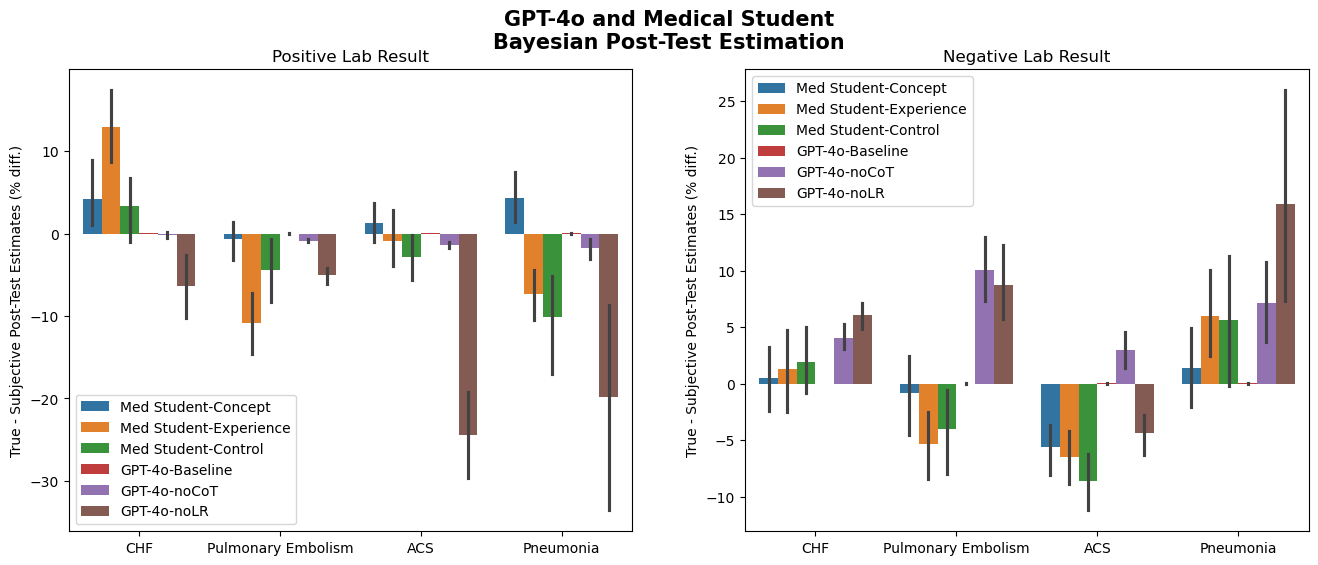

In [64]:
fig, axes = plt.subplots(1,2, figsize=(16,6), sharex=True, sharey=False,
                         # dpi=300
                        )

disease_order = ['CHF', 'Pulmonary Embolism', 'ACS', 'Pneumonia']
testcond_order1 = ['Med Student-Concept', 'Med Student-Experience',
        'Med Student-Control', 'GPT-4o-Baseline', 'GPT-4o-noCoT',
        'GPT-4o-noLR']

sns.barplot(gptlarge_medstudent_combined[gptlarge_medstudent_combined['positive'] == "POS"], x="case_type", y='posttest_prob_diff', hue="subject-testcond", ax=axes[0], hue_order=testcond_order1, order=disease_order)
axes[0].set_ylabel("True - Subjective Post-Test Estimates (% diff.)")
axes[0].set_xlabel(None)
axes[0].set_title("Positive Lab Result")
axes[0].legend().set_title(None)
# handles, labels = axes[0].get_legend_handles_labels()
# # sort both labels and handles by labels
# labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
# axes[0].legend(handles, labels, loc="lower right", title="Treatment")
# axes[0].set_xticklabels(labels=['Acute Coronary\nSyndrome', "Pulmonary Embolism", "Pneumonia", ""])

sns.barplot(gptlarge_medstudent_combined[gptlarge_medstudent_combined['positive'] == "NEG"], x="case_type", y='posttest_prob_diff', hue="subject-testcond", ax=axes[1], hue_order=testcond_order1, order=disease_order)
axes[1].set_ylabel("True - Subjective Post-Test Estimates (% diff.)")
axes[1].set_xlabel(None)
axes[1].set_title("Negative Lab Result")
axes[1].legend().set_title(None)
fig.suptitle("GPT-4o and Medical Student\nBayesian Post-Test Estimation", size=15, weight="bold")
plt.setp( axes[0].xaxis.get_majorticklabels(), rotation=0 )
plt.setp( axes[1].xaxis.get_majorticklabels(), rotation=0 )

plt.savefig(f"gpt4olarge_medstudent_posttestprob.svg",   bbox_inches="tight")

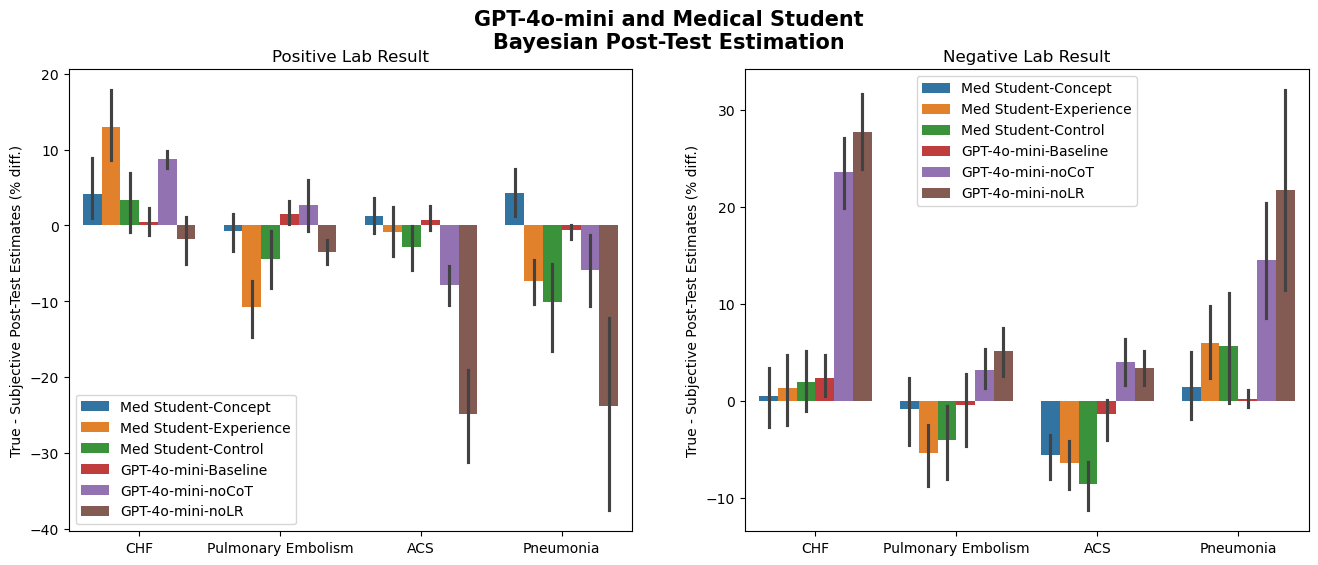

In [65]:
fig, axes = plt.subplots(1,2, figsize=(16,6), sharex=True, sharey=False,
                         # dpi=300
                        )

disease_order = ['CHF', 'Pulmonary Embolism', 'ACS', 'Pneumonia']
testcond_order2 = ['Med Student-Concept', 'Med Student-Experience',
        'Med Student-Control', 'GPT-4o-mini-Baseline', 'GPT-4o-mini-noCoT',
        'GPT-4o-mini-noLR']

sns.barplot(gptmini_medstudent_combined[gptmini_medstudent_combined['positive'] == "POS"], x="case_type", y='posttest_prob_diff', hue="subject-testcond", ax=axes[0], hue_order=testcond_order2, order=disease_order)
axes[0].set_ylabel("True - Subjective Post-Test Estimates (% diff.)")
axes[0].set_xlabel(None)
axes[0].set_title("Positive Lab Result")
axes[0].legend().set_title(None)
# handles, labels = axes[0].get_legend_handles_labels()
# # sort both labels and handles by labels
# labels, handles = zip(*sorted(zip(labels, handles), key=lambda t: t[0]))
# axes[0].legend(handles, labels, loc="lower right", title="Treatment")
# axes[0].set_xticklabels(labels=['Acute Coronary\nSyndrome', "Pulmonary Embolism", "Pneumonia", ""])

sns.barplot(gptmini_medstudent_combined[gptmini_medstudent_combined['positive'] == "NEG"], x="case_type", y='posttest_prob_diff', hue="subject-testcond", ax=axes[1], hue_order=testcond_order2, order=disease_order)
axes[1].set_ylabel("True - Subjective Post-Test Estimates (% diff.)")
axes[1].set_xlabel(None)
axes[1].set_title("Negative Lab Result")
axes[1].legend().set_title(None)
fig.suptitle("GPT-4o-mini and Medical Student\nBayesian Post-Test Estimation", size=15, weight="bold")
plt.setp( axes[0].xaxis.get_majorticklabels(), rotation=0 )
plt.setp( axes[1].xaxis.get_majorticklabels(), rotation=0 )

plt.savefig(f"gpt4omini_medstudent_posttestprob.svg",   bbox_inches="tight")

In [55]:
# sns.barplot(all_gpt_combined_df[all_gpt_combined_df['positive'] == "POS"], x="case_type", y='bayes_diff', hue="subject-CONDITION", ax=axes[0])
# sns.barplot(all_gpt_combined_df[all_gpt_combined_df['positive'] == "NEG"], x="case_type", y='bayes_diff', hue="subject-CONDITION", ax=axes[1])
